### imports

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

### Paths

In [2]:
REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

INTERIM_DIR = REPO_ROOT / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

DIM_PATH = INTERIM_DIR / "dim_neighbourhoods.parquet"

print("DIM_PATH:", DIM_PATH)

DIM_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\interim\dim_neighbourhoods.parquet


### Load neighbourhood dimension

In [3]:
dim = gpd.read_parquet(DIM_PATH)

print("dim shape:", dim.shape)
print(dim.columns.tolist())
dim.head()

dim shape: (158, 4)
['area_id', 'area_name', 'nbhd_id', 'geometry']


,area_id,area_name,nbhd_id,geometry
0,2502366,South Eglinton-Davisville,174,"MULTIPOLYGON (((-79.38635 43.69783, -79.38623 ..."
1,2502365,North Toronto,173,"MULTIPOLYGON (((-79.39744 43.70693, -79.39837 ..."
2,2502364,Dovercourt Village,172,"MULTIPOLYGON (((-79.43411 43.66015, -79.43537 ..."
3,2502363,Junction-Wallace Emerson,171,"MULTIPOLYGON (((-79.4387 43.66766, -79.43841 4..."
4,2502362,Yonge-Bay Corridor,170,"MULTIPOLYGON (((-79.38404 43.64497, -79.38502 ..."


### Keep only required columns and ensure geometry

In [4]:
dim = dim[["nbhd_id", "area_name", "geometry"]].copy()
dim = gpd.GeoDataFrame(dim, geometry="geometry", crs="EPSG:4326")

assert dim["nbhd_id"].isna().sum() == 0, "nbhd_id contains nulls"
assert dim["nbhd_id"].nunique() == len(dim), "nbhd_id should be unique per neighbourhood"

print("Neighbourhood count:", len(dim))

Neighbourhood count: 158


### Reproject for safer geometric operations

In [5]:
# Reproject to a metric CRS for safer topology operations
# EPSG:3978 = Canada Atlas Lambert (good general-purpose projected CRS for Canada)
dim_proj = dim.to_crs(epsg=3978)

print("Projected CRS:", dim_proj.crs)
dim_proj.head()

Projected CRS: EPSG:3978


,nbhd_id,area_name,geometry
0,174,South Eglinton-Davisville,"MULTIPOLYGON (((1275901.58 -438709.79, 1275920..."
1,173,North Toronto,"MULTIPOLYGON (((1274762.572 -437927.954, 12746..."
2,172,Dovercourt Village,"MULTIPOLYGON (((1273115.85 -443826.543, 127302..."
3,171,Junction-Wallace Emerson,"MULTIPOLYGON (((1272541.076 -443088.632, 12725..."
4,170,Yonge-Bay Corridor,"MULTIPOLYGON (((1277548.65 -444498.324, 127747..."


### Build adjacency pairs using touches

In [6]:
adj_pairs = []

for i, row_i in dim_proj.iterrows():
    geom_i = row_i.geometry
    id_i = row_i.nbhd_id

    # Find all polygons that touch this one
    mask = dim_proj.geometry.touches(geom_i)

    # Remove self if ever present
    neighbors = dim_proj.loc[mask, "nbhd_id"].tolist()
    neighbors = [n for n in neighbors if n != id_i]

    for n in neighbors:
        adj_pairs.append((id_i, n))

adj_df = pd.DataFrame(adj_pairs, columns=["nbhd_id", "adjacent_nbhd_id"])

print("Adjacency raw rows:", adj_df.shape)
adj_df.head(10)

Adjacency raw rows: (854, 2)


,nbhd_id,adjacent_nbhd_id
0,174,173
1,174,100
2,174,97
3,173,174
4,173,100
5,173,99
6,172,95
7,172,94
8,172,83
9,171,94


### Clean duplicates and sort

In [7]:
adj_df["nbhd_id"] = pd.to_numeric(adj_df["nbhd_id"], errors="coerce").astype(int)
adj_df["adjacent_nbhd_id"] = pd.to_numeric(adj_df["adjacent_nbhd_id"], errors="coerce").astype(int)

adj_df = adj_df.drop_duplicates().sort_values(["nbhd_id", "adjacent_nbhd_id"]).reset_index(drop=True)

print("Adjacency cleaned rows:", adj_df.shape)
adj_df.head(20)

Adjacency cleaned rows: (854, 2)


,nbhd_id,adjacent_nbhd_id
0,1,3
1,1,4
2,1,5
3,1,6
4,1,7
5,1,11
6,2,3
7,2,4
8,2,21
9,2,22


### Sanity checks

In [8]:
# Each neighbourhood should usually have at least 1 neighbor
coverage = adj_df["nbhd_id"].nunique()
print("Neighbourhoods with at least one adjacent neighbour:", coverage)

isolated = set(dim["nbhd_id"]) - set(adj_df["nbhd_id"])
print("Isolated neighbourhoods:", isolated)

adj_counts = adj_df.groupby("nbhd_id").size().rename("n_neighbors").reset_index()
print(adj_counts.describe())
adj_counts.head(10)

Neighbourhoods with at least one adjacent neighbour: 158
Isolated neighbourhoods: set()
          nbhd_id  n_neighbors
count  158.000000   158.000000
mean    88.107595     5.405063
std     51.236381     1.670417
min      1.000000     2.000000
25%     43.250000     4.000000
50%     88.500000     5.000000
75%    133.750000     6.000000
max    174.000000    11.000000


,nbhd_id,n_neighbors
0,1,6
1,2,4
2,3,6
3,4,3
4,5,5
5,6,6
6,7,5
7,8,5
8,9,5
9,10,4


### symmetric check

In [9]:
pairs = set(tuple(x) for x in adj_df[["nbhd_id", "adjacent_nbhd_id"]].to_numpy())
reverse_missing = []

for a, b in pairs:
    if (b, a) not in pairs:
        reverse_missing.append((a, b))

print("Reverse-missing adjacency pairs:", len(reverse_missing))
reverse_missing[:10]

Reverse-missing adjacency pairs: 0


[]

### Save

In [10]:
out_path = INTERIM_DIR / "nbhd_adjacency.parquet"
adj_df.to_parquet(out_path, index=False)

print("Saved:", out_path)

Saved: C:\code\pyspark-playground\Covercheck-Toronto\data\interim\nbhd_adjacency.parquet


### EDA

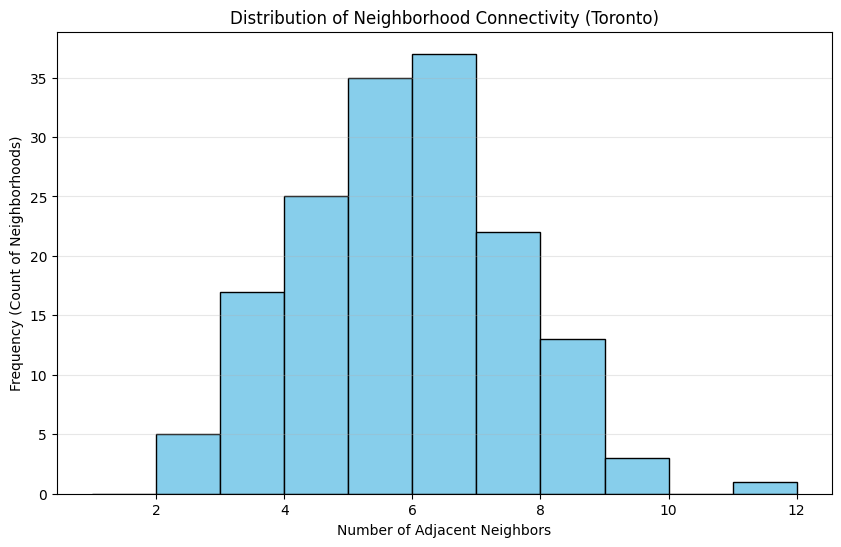

Direct construction impact: 2 neighborhoods
Halo impact (Self + Neighbors): 9 unique neighborhoods


In [11]:
import matplotlib.pyplot as plt

#visualizing neighborhood connectivity
plt.figure(figsize=(10, 6))
plt.hist(adj_counts['n_neighbors'], bins=range(1, 13), color='skyblue', edgecolor='black')
plt.title('Distribution of Neighborhood Connectivity (Toronto)')
plt.xlabel('Number of Adjacent Neighbors')
plt.ylabel('Frequency (Count of Neighborhoods)')
plt.grid(axis='y', alpha=0.3)
plt.show()

#previewing the "Halo" effect for active construction sites
#known active neighborhoods from 09B
target_nbhds = [150, 156] # Example IDs for Fenside-Parkwoods / West Humber-Clairville
halo_coverage = adj_df[adj_df['nbhd_id'].isin(target_nbhds)]

print(f"Direct construction impact: {len(target_nbhds)} neighborhoods")
print(f"Halo impact (Self + Neighbors): {halo_coverage['adjacent_nbhd_id'].nunique() + len(target_nbhds)} unique neighborhoods")